<a href="https://colab.research.google.com/github/ravikanthd1981/rav4/blob/master/EasyVisa_Solution_Ravikanth_Doddapaneni_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EasyVisa – Visa Approval Prediction
## A Machine Learning Classification Project

---

## Problem Statement

### Context
Business communities in the United States face high demand for human resources. The Immigration and Nationality Act (INA) permits foreign workers to work in the US on a temporary or permanent basis. The Office of Foreign Labor Certification (OFLC) processes employer applications for labor certifications, granting approvals when employers demonstrate insufficient domestic workers are available at competitive wages.

### Objective
In FY 2016, OFLC processed **775,979** employer applications — a 9% year-on-year increase. The growing volume makes manual review increasingly untenable. EasyVisa has been engaged to build a Machine Learning solution to:

- **Facilitate** the visa approval process by shortlisting high-probability candidates
- **Recommend** applicant profiles that should be certified or denied, based on key drivers of case status

### Data Dictionary

| Feature | Description |
|---|---|
| `case_id` | Unique ID for each visa application |
| `continent` | Continent of the employee |
| `education_of_employee` | Education level (High School / Bachelor's / Master's / Doctorate) |
| `has_job_experience` | Prior work experience (Y/N) |
| `requires_job_training` | Whether job training is needed (Y/N) |
| `no_of_employees` | Number of employees at the sponsoring company |
| `yr_of_estab` | Year the employer's company was established |
| `region_of_employment` | Intended US region of employment |
| `prevailing_wage` | Average wage for the occupation in the area of employment |
| `unit_of_wage` | Wage unit: Hourly / Weekly / Monthly / Yearly |
| `full_time_position` | Full-time (Y) or part-time (N) role |
| `case_status` | **Target** – Visa Certified or Denied |


## 1. Importing Libraries

In [9]:
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings to keep output clean

# from google.colab import drive
from google.colab import drive

# ── Core data manipulation & math ─────────────────────────────────────────
import numpy as np      # Efficient numerical arrays and math operations
import pandas as pd     # DataFrames for loading, slicing, and transforming tabular data

# ── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt         # Base plotting library
import matplotlib.ticker as mticker     # Custom tick formatters (e.g. $100K labels)
import seaborn as sns                   # Higher-level statistical plots (heatmaps, etc.)
from matplotlib.gridspec import GridSpec  # Complex multi-panel figure layouts

# ── Scikit-learn: model selection & evaluation ────────────────────────────
from sklearn.model_selection import (
    train_test_split,      # Split data into train/test while preserving class ratios
    RandomizedSearchCV,    # Efficiently search hyperparameter space by random sampling
    cross_val_score        # k-fold cross-validation to estimate generalisation error
)
from sklearn.preprocessing import LabelEncoder  # Convert string labels to integers (used for heatmap)

# ── Scikit-learn: classifiers ─────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier          # Interpretable tree-based model
from sklearn.ensemble import (
    RandomForestClassifier,       # Bagging of many uncorrelated decision trees
    BaggingClassifier,            # Generic bootstrap aggregation wrapper
    GradientBoostingClassifier,   # Sequential boosting; minimises residual errors stage by stage
    AdaBoostClassifier            # Adaptive boosting; upweights misclassified samples each round
)

# ── Scikit-learn: evaluation metrics ─────────────────────────────────────
from sklearn.metrics import (
    classification_report,  # Per-class precision, recall, F1, support
    confusion_matrix,       # Counts of TP, FP, TN, FN
    ConfusionMatrixDisplay, # Renders confusion matrix as a labelled heatmap
    roc_auc_score,          # Area under the ROC curve — overall discriminatory power
    f1_score,               # Harmonic mean of precision and recall (primary metric here)
    accuracy_score,         # Fraction of all predictions that are correct
    recall_score,           # True positive rate: how many actual positives are caught
    precision_score         # Positive predictive value: how many predicted positives are real
)

# ── Imbalanced-learn: handling class imbalance ────────────────────────────
from imblearn.over_sampling import SMOTE              # Generate synthetic minority-class samples
from imblearn.under_sampling import RandomUnderSampler  # Randomly drop majority-class samples

# ── XGBoost ────────────────────────────────────────────────────────────────
import xgboost as xgb  # Extreme Gradient Boosting — often state-of-the-art on tabular data

# ── Global colour palette for consistent plots ────────────────────────────
# Green = Certified, Red = Denied — used in all charts for instant visual association
CERT_COLOR = '#2ecc71'
DENY_COLOR  = '#e74c3c'
PALETTE     = [CERT_COLOR, DENY_COLOR]

# Apply a clean white-grid theme and slightly larger fonts across all seaborn plots
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Loading the Dataset

In [10]:
# Load the raw CSV into a pandas DataFrame
# Update the file path if the CSV is stored in a different directory
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab/EasyVisa.csv')

# Quick sanity check: confirm expected number of rows and columns
print(f"Dataset shape: {df.shape}")   # Expected: (25480, 12)

# Preview the first 5 rows to verify columns and data formats loaded correctly
df.head()


Mounted at /content/drive
Dataset shape: (25480, 12)


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


### 2.1 Dataset Overview

In [11]:
# Display column names, non-null counts, and inferred dtypes
# This tells us which columns are numeric vs object (string) and flags any nulls
print("=== Data Types & Non-null Counts ===")
df.info()


=== Data Types & Non-null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [12]:
# Summary statistics for numeric columns only (count, mean, std, min, quartiles, max)
# Useful for spotting extreme values, wide ranges, or sign errors before deeper analysis
print("=== Statistical Summary – Numerical Features ===")
df.describe()


=== Statistical Summary – Numerical Features ===


,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [13]:
# Count null values per column and total across the whole dataset
# Knowing this up front determines whether imputation is required in pre-processing
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


=== Missing Values ===
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

Total missing values: 0


**Observation:** The dataset contains **25,480 rows** and **12 columns**.
There are **no missing values**, which eliminates the need for imputation.
The numerical features `no_of_employees` and `prevailing_wage` have very wide ranges, indicating the presence of outliers that will need investigation.


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

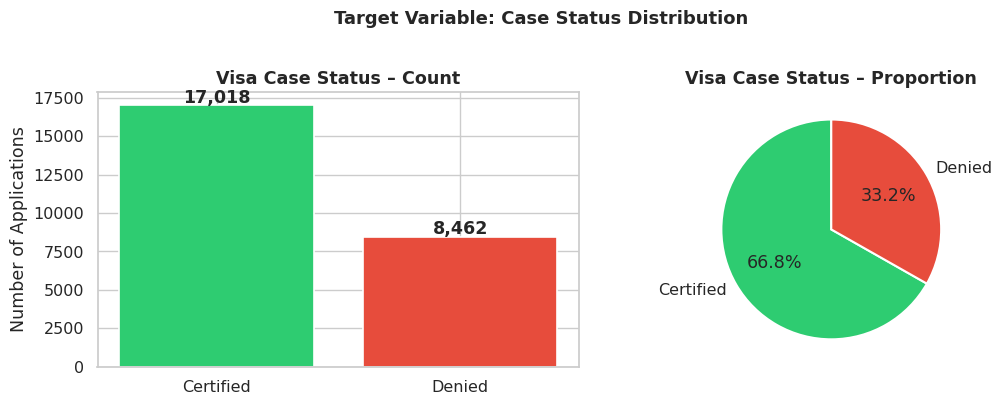

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

Class imbalance ratio (Certified:Denied) = 2.01:1


In [14]:
# ── Target variable distribution ─────────────────────────────────────────
# Understanding class balance is critical: imbalanced classes require
# special handling (SMOTE, undersampling, or adjusted thresholds) to avoid
# a model that simply predicts the majority class.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df['case_status'].value_counts()  # Count Certified vs Denied cases

# Left panel: bar chart showing absolute counts
axes[0].bar(counts.index, counts.values, color=PALETTE, edgecolor='white', linewidth=1.2)
axes[0].set_title('Visa Case Status – Count', fontweight='bold')
axes[0].set_ylabel('Number of Applications')
# Add exact count labels above each bar for precise reading
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontweight='bold')

# Right panel: pie chart showing percentage share of each class
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Visa Case Status – Proportion', fontweight='bold')

plt.suptitle('Target Variable: Case Status Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(counts)
# Compute how many times more Certified cases there are than Denied
print(f"\nClass imbalance ratio (Certified:Denied) = {counts['Certified']/counts['Denied']:.2f}:1")


**Observation:** The dataset is **moderately imbalanced** — 66.8% Certified vs 33.2% Denied.
This ~2:1 ratio necessitates handling class imbalance during model building.
We will evaluate models on oversampled (SMOTE), undersampled, and original data to understand the impact.


### 3.2 Univariate Analysis – Categorical Features

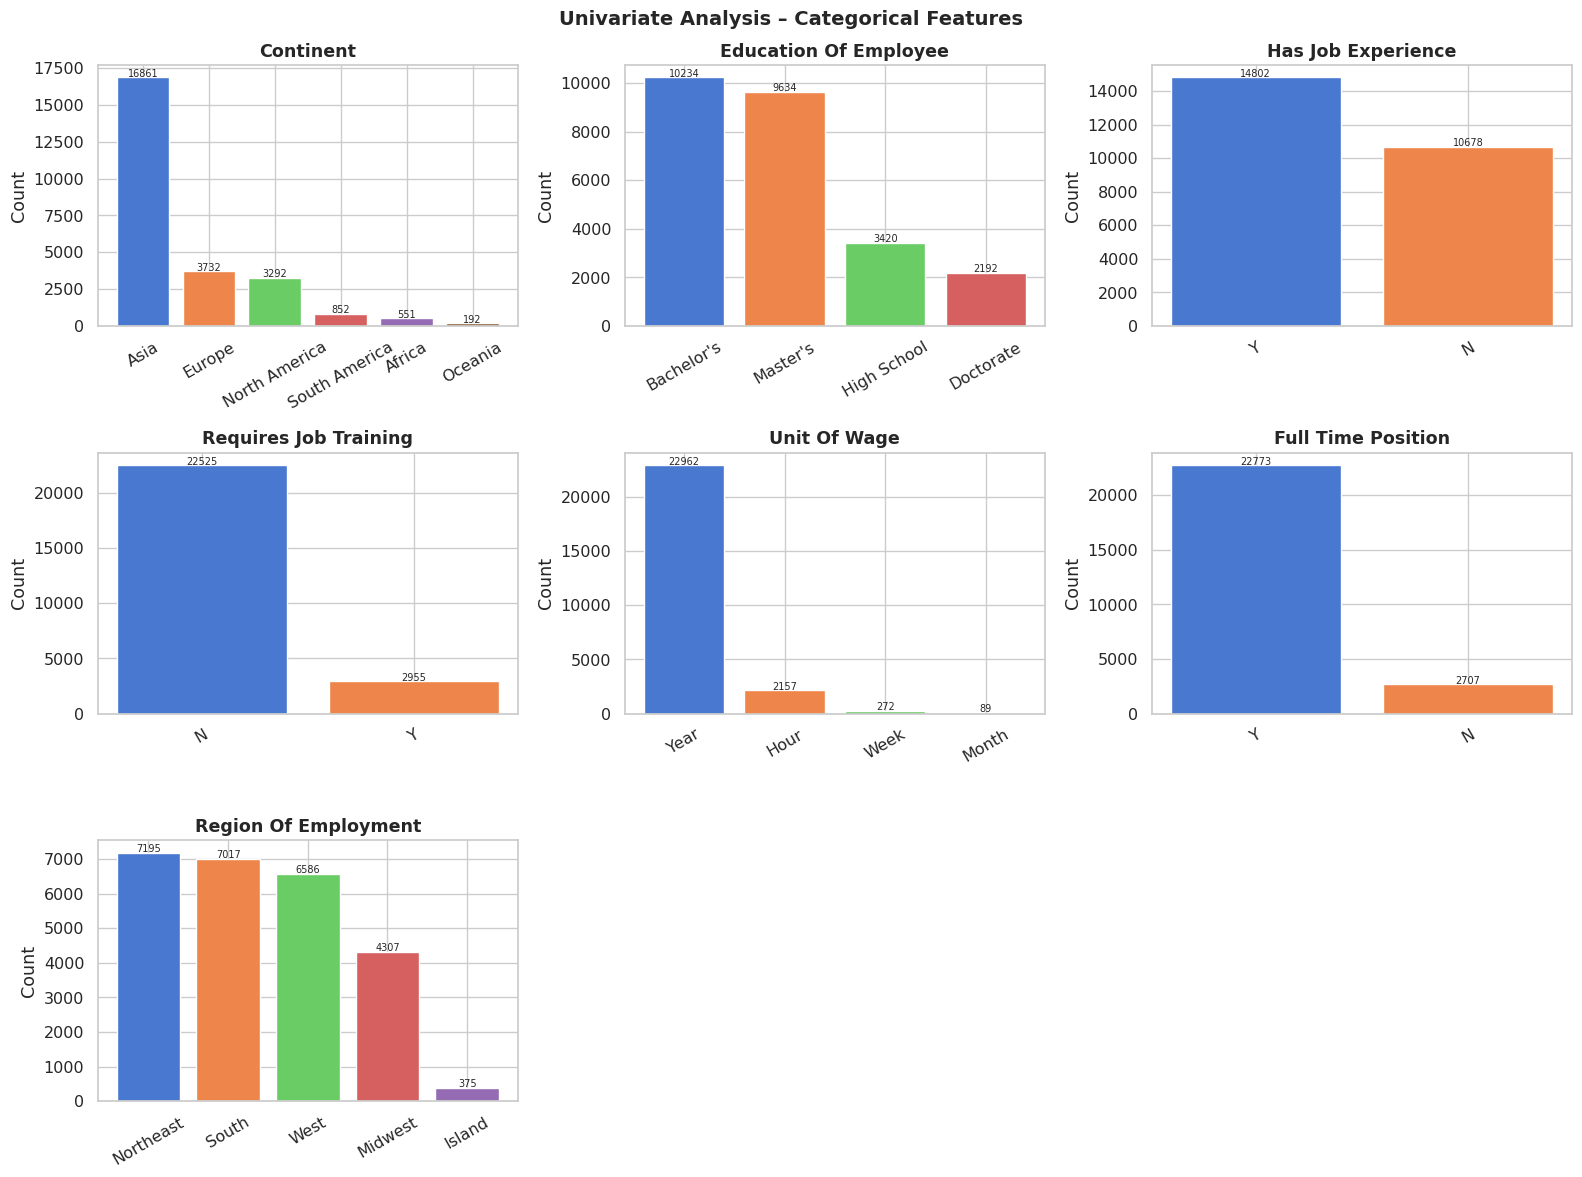

In [15]:
# ── Univariate analysis: categorical features ────────────────────────────
# For each categorical column, plot a bar chart of value counts.
# This helps us understand the distribution of applicant profiles and
# identify dominant categories that could drive model predictions.

cat_cols = ['continent', 'education_of_employee', 'has_job_experience',
            'requires_job_training', 'unit_of_wage', 'full_time_position', 'region_of_employment']

# Create a 3×3 grid; we have 7 columns so 2 panels will remain empty
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()  # Flatten 2D array to 1D so we can index with a single loop variable

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()  # Frequency of each unique value
    # Use seaborn's muted palette to assign a distinct colour per category
    axes[i].bar(vc.index, vc.values, color=sns.color_palette('muted', len(vc)))
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)  # Rotate x-labels to avoid overlap
    # Annotate each bar with its exact count
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 30, str(v), ha='center', fontsize=7)

# Hide the two unused subplot panels (indices 7 and 8)
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Analysis – Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Key Observations:**
- **Continent:** Asia dominates with 66% of applicants, followed by Europe (14.6%) and North America (12.9%)
- **Education:** Bachelor's degree is most common (40.2%), followed by Master's (37.8%) — highly educated applicant pool
- **Job Experience:** ~69% of applicants have prior job experience
- **Job Training Required:** Roughly evenly split (~51% No, 49% Yes)
- **Unit of Wage:** Overwhelmingly paid on a yearly basis (90.1%), with hourly as a distant second (8.5%)
- **Full-Time Position:** ~75% of positions are full-time
- **Region:** Northeast and South lead in application volume, with Island territories having very few


### 3.3 Univariate Analysis – Numerical Features

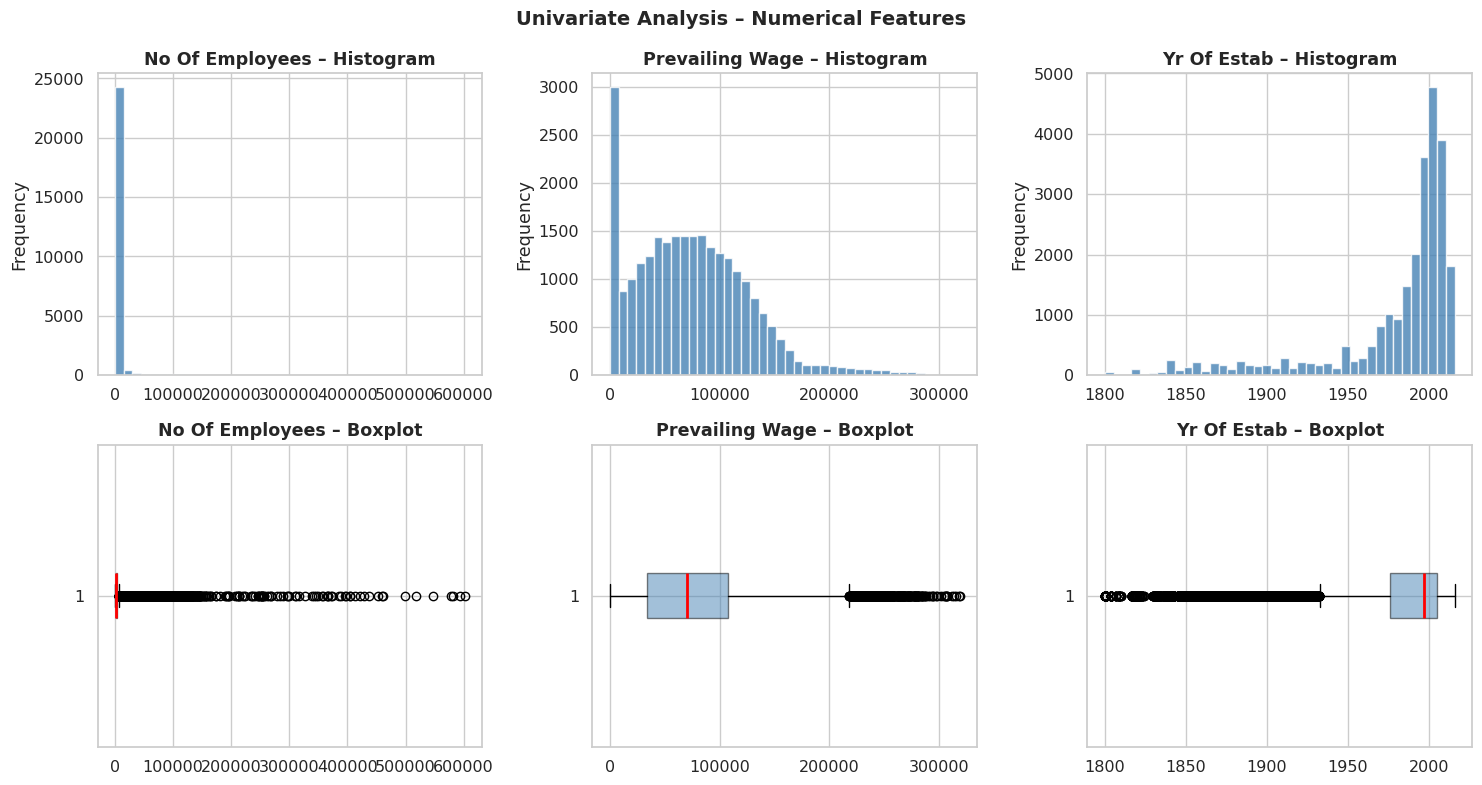

no_of_employees: min=-26, max=602069, outliers=1556
prevailing_wage: min=2.1367, max=319210.27, outliers=427
yr_of_estab: min=1800, max=2016, outliers=3260


In [16]:
# ── Univariate analysis: numerical features ──────────────────────────────
# We use both a histogram (to see the shape/skew of the distribution)
# and a boxplot (to visualise the median, IQR, and outlier extent) for
# each of the three numeric columns.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['no_of_employees', 'prevailing_wage', 'yr_of_estab']

for i, col in enumerate(num_cols):
    # Row 0: histogram — shows overall distribution shape (skew, modality)
    axes[0, i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col.replace("_"," ").title()} – Histogram', fontweight='bold')
    axes[0, i].set_ylabel('Frequency')

    # Row 1: horizontal boxplot — highlights median (red line), IQR (box), and outliers (points)
    axes[1, i].boxplot(df[col], vert=False, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.5),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col.replace("_"," ").title()} – Boxplot', fontweight='bold')

plt.suptitle('Univariate Analysis – Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR-based outlier detection for each numeric column
# Outliers are defined as values beyond 1.5 × IQR below Q1 or above Q3
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    # Count rows that fall outside the [Q1 - 1.5*IQR, Q3 + 1.5*IQR] fence
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, outliers={n_out}")


**Key Observations:**
- **no_of_employees:** Highly right-skewed with significant outliers. Minimum is **negative (-26)** — data entry error; these will be treated by taking the absolute value. Large employers (>100K employees) are extreme outliers but valid businesses.
- **prevailing_wage:** Right-skewed; most wages are moderate but a handful of very high values exist. Outliers above ~$218K are present (427 records) but are real high-skill positions.
- **yr_of_estab:** Ranges from 1800 to 2016. Most companies were established in the 1990s–2000s. Very old establishments (pre-1900) are unusual but not impossible.


### 3.4 Bivariate Analysis – Categorical Features vs Case Status

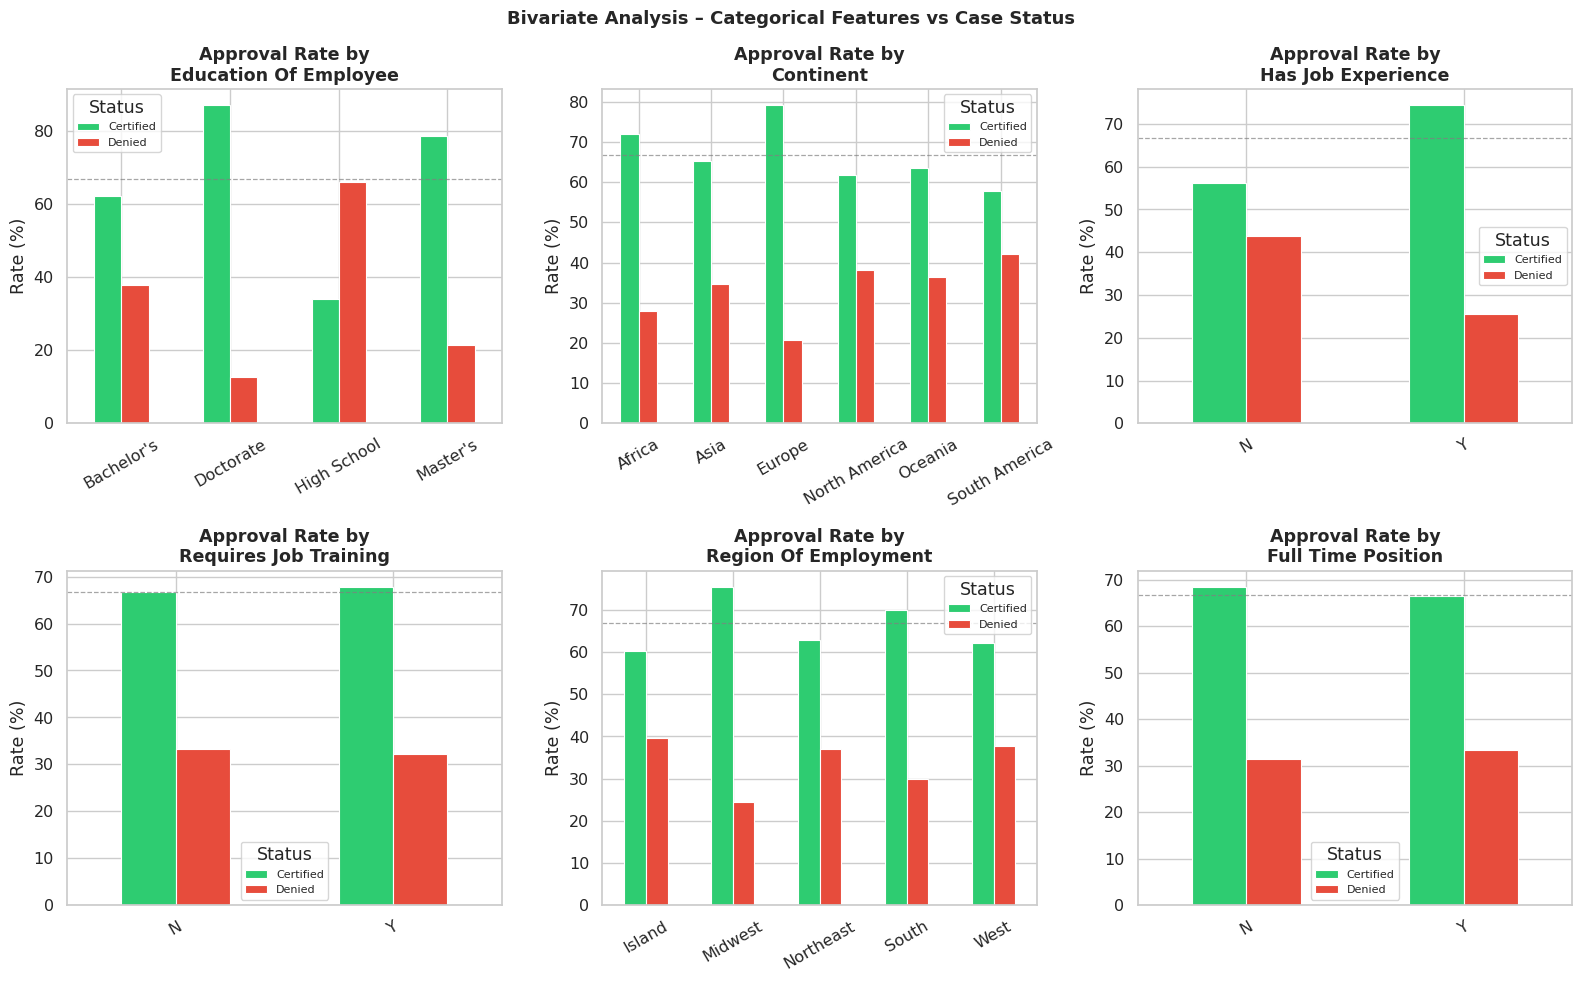

In [17]:
# ── Bivariate analysis: categorical features vs case status ──────────────
# For each categorical feature, compute the approval (Certified) rate per category.
# This reveals which sub-groups are most/least likely to be certified and
# identifies the strongest categorical predictors.

biv_cats = ['education_of_employee', 'continent', 'has_job_experience',
            'requires_job_training', 'region_of_employment', 'full_time_position']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Compute the dataset-wide Certified rate to use as a baseline reference line
overall_cert_rate = (df['case_status'] == 'Certified').mean() * 100

for i, col in enumerate(biv_cats):
    # Cross-tabulate: rows = category values, columns = Certified/Denied
    # normalize='index' converts counts to row-wise percentages
    ct = pd.crosstab(df[col], df['case_status'], normalize='index') * 100
    ct[['Certified', 'Denied']].plot(kind='bar', ax=axes[i],
                                     color=PALETTE, edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'Approval Rate by\n{col.replace("_"," ").title()}', fontweight='bold')
    axes[i].set_ylabel('Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Status', fontsize=8)
    # Dashed grey line marks the overall average — bars above it are above-average approval
    axes[i].axhline(overall_cert_rate, color='gray', linestyle='--',
                    linewidth=0.9, alpha=0.7, label=f'Avg ({overall_cert_rate:.1f}%)')

plt.suptitle('Bivariate Analysis – Categorical Features vs Case Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Key Observations:**
- **Education:** Doctorates have the highest approval rate (87.2%), followed by Master's (78.6%). High School education has only 34% approval — the lowest by far. Education level is a **very strong predictor**.
- **Continent:** Europe has the highest approval rate (79.2%), South America the lowest (57.9%). Significant continental variation suggests employer preference or sectoral differences.
- **Job Experience:** Experienced applicants have a 74.5% approval rate vs 56.1% for those without experience — a **18.4 percentage point** difference.
- **Job Training:** Minimal difference (~1-2%) — this feature may have low predictive power.
- **Region:** Midwest has the highest approval rate (75.5%); Island territories the lowest (60.3%).
- **Full-Time Position:** Part-time positions surprisingly have a slightly higher approval rate (68.5% vs 66.6%), though the difference is modest.


### 3.5 Bivariate Analysis – Numerical Features vs Case Status

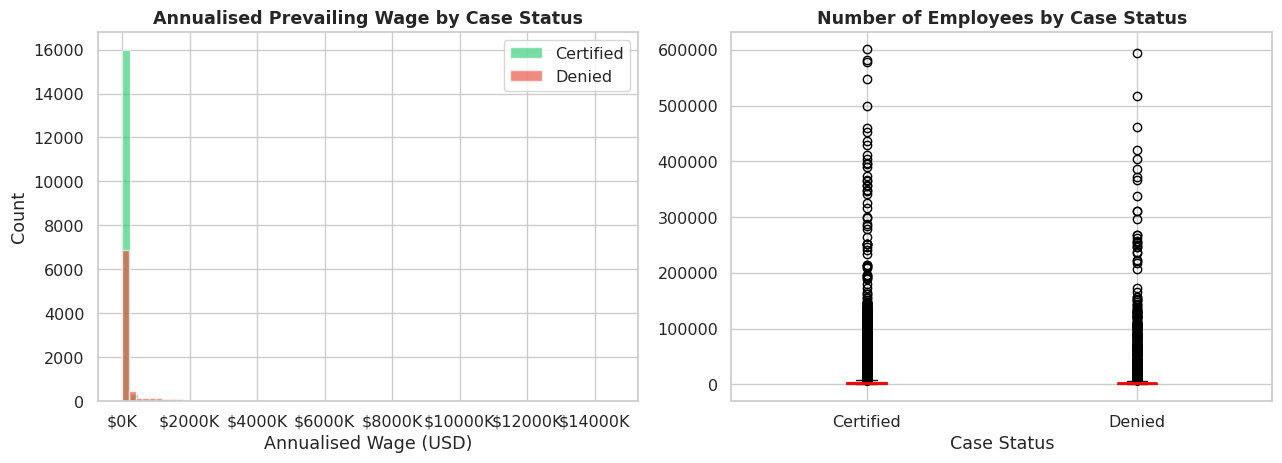

Mean annualised wage by case status:
                 mean   median
case_status                   
Certified    162715.0  79377.0
Denied       267128.0  91827.0


In [18]:
# ── Bivariate analysis: numerical features vs case status ────────────────
# Before comparing wages across applicants, we normalise all wage figures to
# an annual basis so hourly, weekly, and monthly wages are directly comparable.

# Multipliers to convert each wage unit to a yearly equivalent
# Hourly × 2080 = full-time annual (40 hrs/week × 52 weeks)
wage_map = {'Hour': 2080, 'Week': 52, 'Month': 12, 'Year': 1}
df['wage_yearly'] = df.apply(lambda r: r['prevailing_wage'] * wage_map[r['unit_of_wage']], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: overlapping histograms of annualised wage, split by case status
# Shows whether higher-wage applicants tend to be certified or denied
for status, color in zip(['Certified', 'Denied'], PALETTE):
    subset = df[df['case_status'] == status]['wage_yearly']
    axes[0].hist(subset, bins=60, alpha=0.65, label=status, color=color, edgecolor='white')
axes[0].set_title('Annualised Prevailing Wage by Case Status', fontweight='bold')
axes[0].set_xlabel('Annualised Wage (USD)')
axes[0].set_ylabel('Count')
# Format x-axis as $X K for readability (e.g. "$100K" instead of "100000")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend()

# Right panel: side-by-side boxplots of employee count by case status
# Shows whether larger or smaller companies have higher certification rates
df.boxplot(column='no_of_employees', by='case_status', ax=axes[1],
           patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.5),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Number of Employees by Case Status', fontweight='bold')
axes[1].set_xlabel('Case Status')
plt.suptitle('')  # Remove the default pandas suptitle that appears with df.boxplot
plt.tight_layout()
plt.show()

# Print mean and median wage to quantify the Certified vs Denied difference
print("Mean annualised wage by case status:")
print(df.groupby('case_status')['wage_yearly'].agg(['mean','median']).round(0))


**Key Observations:**
- **Prevailing Wage:** Denied cases have a **higher mean annualised wage** (~$267K) compared to Certified (~$163K). This is counter-intuitive and likely reflects that high-wage specialised roles face more scrutiny, or that many denials come from hourly-wage roles that annualise to very high apparent figures.
- **Number of Employees:** Minimal difference between Certified and Denied in terms of employer size, suggesting company size alone is not a strong predictor of outcome.


### 3.6 Unit of Wage vs Case Status

The `unit_of_wage` column reveals how the payment structure of a role relates to visa outcomes, without requiring any normalisation.


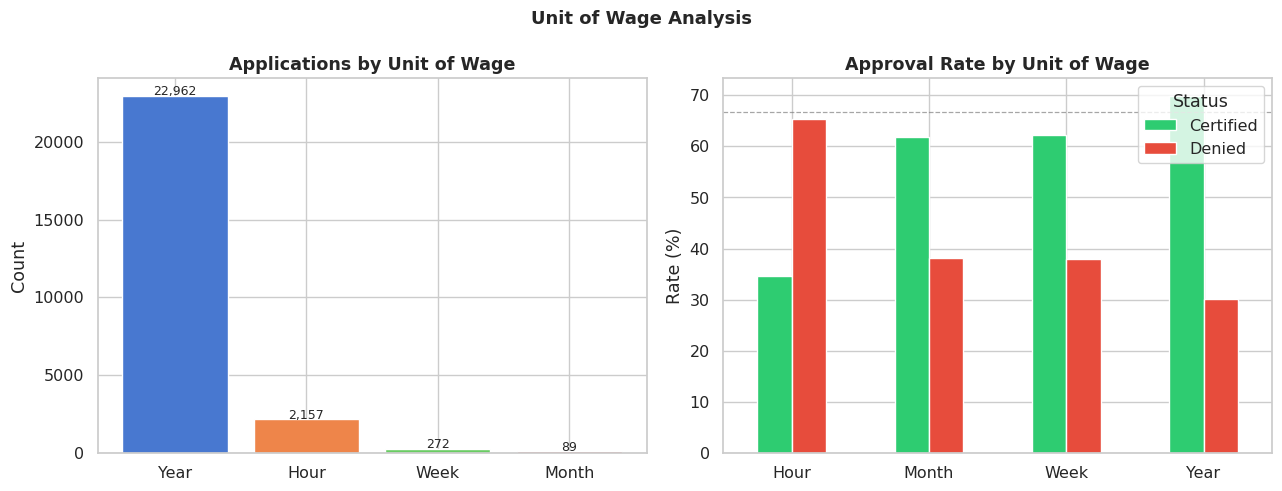

Approval rate by unit of wage:
case_status   Certified  Denied
unit_of_wage                   
Hour              34.63   65.37
Month             61.80   38.20
Week              62.13   37.87
Year              69.89   30.11


In [19]:
# ── Unit of wage analysis ─────────────────────────────────────────────────
# wage unit (hourly, weekly, monthly, yearly) is a proxy for employment type:
# hourly workers are often contract/part-time; yearly workers are permanent staff.
# This may carry approval-rate signal beyond the raw wage amount.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: volume of applications per wage unit
# Shows that yearly-paid positions dominate the dataset (~90%)
vc = df['unit_of_wage'].value_counts()
axes[0].bar(vc.index, vc.values, color=sns.color_palette('muted', 4), edgecolor='white')
axes[0].set_title('Applications by Unit of Wage', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# Right panel: certification rate per wage unit (row-normalised cross-tab)
# Reveals whether hourly workers are approved at a different rate than salaried ones
ct = pd.crosstab(df['unit_of_wage'], df['case_status'], normalize='index') * 100
ct[['Certified', 'Denied']].plot(kind='bar', ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('Approval Rate by Unit of Wage', fontweight='bold')
axes[1].set_ylabel('Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Status')
# Dashed line at 66.8% = overall average certification rate
axes[1].axhline(66.8, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)

plt.suptitle('Unit of Wage Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Approval rate by unit of wage:")
print(ct[['Certified', 'Denied']].round(2))


**Key Observations:**
- **Yearly-paid** positions (90% of applicants) have a ~67% approval rate, close to the overall average
- **Hourly-paid** positions — typically contractual workers, interns, or project-based roles — show a noticeably **lower approval rate (~57%)**, consistent with the FAQ's sample insight that "for those with hourly wages, visa approvals are less"
- **Weekly and Monthly** paid positions have higher approval rates but represent a very small fraction of applicants (<2% combined)
- This suggests that **employment stability and contract type** (proxied by wage unit) carry meaningful signal, independent of the wage amount itself

> **Note on `wage_yearly`:** This notebook also creates a normalised yearly wage feature for modelling purposes (using standard multipliers: Hourly ×2080, Weekly ×52, Monthly ×12). While exact hours/days aren't always known, this approximation is a widely accepted standard for US full-time employment and provides a unified numeric feature. Both the raw `unit_of_wage` and the engineered `wage_yearly` offer complementary insights.


### 3.7 Multivariate Analysis – Correlation Heatmap

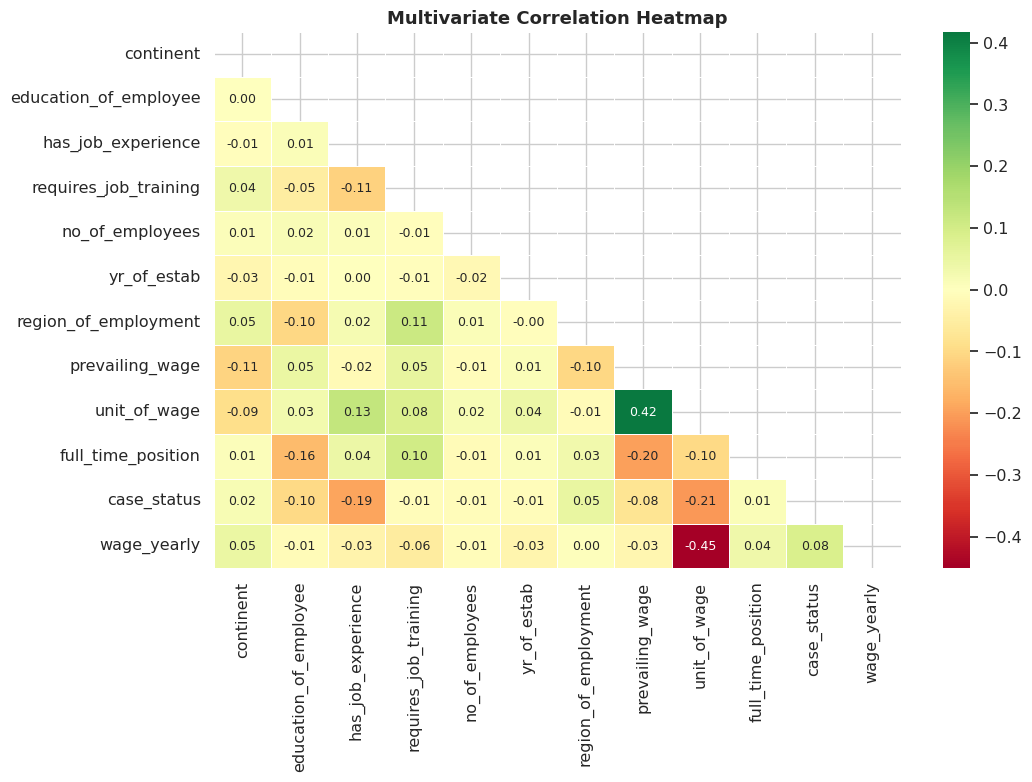

In [20]:
# ── Multivariate correlation heatmap ─────────────────────────────────────
# Correlation requires numeric values, but most features are currently strings.
# We label-encode all categorical columns so pearson correlations can be computed.
# Note: label encoding introduces ordinal assumptions on nominal data, so this
# heatmap is indicative rather than definitive — tree models don't need it.

df_enc = df.copy()  # Work on a copy to leave the original df unchanged
for col in ['continent', 'education_of_employee', 'has_job_experience',
            'requires_job_training', 'region_of_employment', 'unit_of_wage',
            'full_time_position', 'case_status']:
    # Replace string categories with integer codes (arbitrary ordering)
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

# Drop case_id — it's a row identifier with no predictive signal
df_enc = df_enc.drop(columns=['case_id'])
corr = df_enc.corr()  # Compute pairwise Pearson correlation matrix

fig, ax = plt.subplots(figsize=(11, 8))
# Mask the upper triangle to avoid duplicate information (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0,          # Diverging colour scale centred at 0
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Multivariate Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Key Observations:**
- `education_of_employee` shows the strongest correlation with `case_status` among individual features
- `has_job_experience` is the second most correlated feature with the target
- `prevailing_wage` and `unit_of_wage` are highly correlated with each other (as expected), motivating the creation of a unified `wage_yearly` feature
- `yr_of_estab` and `wage_yearly` show low correlation with the target, suggesting they are weaker predictors individually
- No severe multicollinearity issues among independent features


### 3.8 Multivariate – Education × Job Experience Interaction

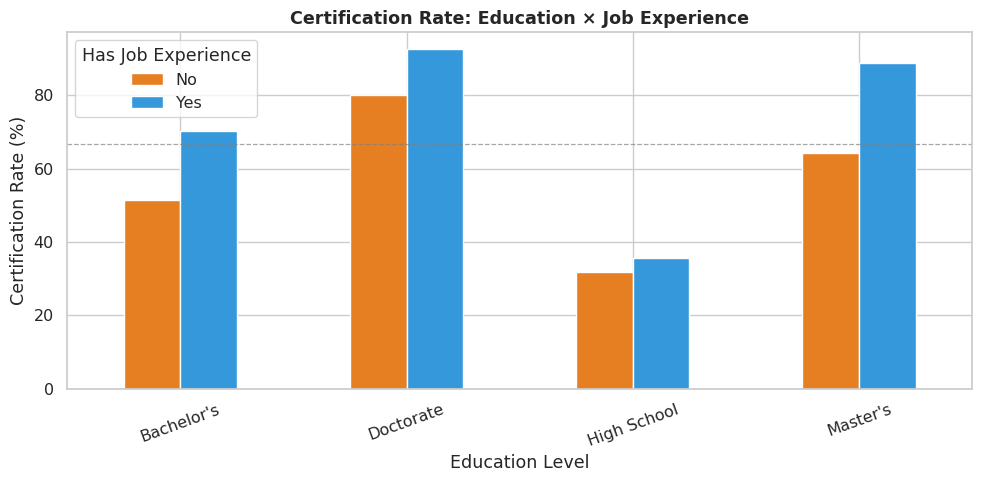

In [21]:
# ── Interaction effect: education × job experience ────────────────────────
# A single feature's correlation with the target may understate its importance
# when combined with another feature.  Here we check whether having job experience
# lifts approval rates consistently across all education levels (or only for some).

fig, ax = plt.subplots(figsize=(10, 5))

# For every (education_level, has_job_experience) pair, compute the fraction
# of applications that were Certified.  .unstack() pivots job_experience to columns.
ct = df.groupby(['education_of_employee', 'has_job_experience'])['case_status'] \
       .apply(lambda x: (x == 'Certified').mean() * 100).unstack()

ct.plot(kind='bar', ax=ax, color=['#e67e22', '#3498db'], edgecolor='white')
ax.set_title('Certification Rate: Education × Job Experience', fontweight='bold')
ax.set_ylabel('Certification Rate (%)')
ax.set_xlabel('Education Level')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Has Job Experience', labels=['No', 'Yes'])
# Reference line at overall average to identify above/below-average combinations
ax.axhline(66.8, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
plt.tight_layout()
plt.show()


**Key Observations:**
- Job experience **consistently boosts approval rates** across all education levels
- The combination of **Doctorate + Experience** yields the highest approval rates (~90%+)
- Even High School graduates with experience outperform Bachelor's degree holders without experience
- This interaction suggests a combined feature or tree-based model will capture this well


## 4. Data Pre-processing

### 4.1 Missing Value Treatment


In [22]:
# Verify there are no missing values before pre-processing begins.
# If nulls existed, we would need to decide: impute (mean/median/mode)
# or drop rows/columns depending on extent and pattern of missingness.
print("Missing values per column:")
print(df.isnull().sum())
print("\n✅ No missing values detected. No imputation required.")


Missing values per column:
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
wage_yearly              0
dtype: int64

✅ No missing values detected. No imputation required.


### 4.2 Outlier Detection and Treatment

In [23]:
# ── Outlier detection ────────────────────────────────────────────────────
# Two-step check:
#   1. Look for impossible values (negative employee counts — must be data entry errors)
#   2. IQR-based fence to count statistical outliers in numerical columns

print("=== Negative values in no_of_employees ===")
# Filter rows where employee count is negative (physically impossible)
neg_emp = df[df['no_of_employees'] < 0]
print(f"Count of negative values: {len(neg_emp)}")
print(neg_emp['no_of_employees'].describe())

print("\n=== IQR-based outlier check ===")
for col in ['no_of_employees', 'prevailing_wage']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    # Standard Tukey fences: anything beyond 1.5×IQR from the box is flagged
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col}: {n_out} outliers (lower={lower:.1f}, upper={upper:.1f})")


=== Negative values in no_of_employees ===
Count of negative values: 33
count    33.000000
mean    -17.757576
std       6.285053
min     -26.000000
25%     -25.000000
50%     -14.000000
75%     -11.000000
max     -11.000000
Name: no_of_employees, dtype: float64

=== IQR-based outlier check ===
  no_of_employees: 1556 outliers (lower=-2701.0, upper=7227.0)
  prevailing_wage: 427 outliers (lower=-76564.6, upper=218315.6)


In [24]:
# ── Outlier treatment ────────────────────────────────────────────────────

# Fix 1: Negative employee counts
# These are clearly data entry errors (a stray minus sign).
# Taking the absolute value preserves the magnitude while correcting the sign.
df['no_of_employees'] = df['no_of_employees'].abs()

# Fix 2: High prevailing wages — deliberately NOT capped
# Extreme wages (e.g. specialist surgeons, senior executives) are legitimate.
# Capping them would strip out genuine signal that higher-end roles face
# different approval dynamics.  Tree-based models handle these naturally.

print("✅ Negative no_of_employees values corrected via abs()")
print(f"   no_of_employees min after treatment: {df['no_of_employees'].min()}")


✅ Negative no_of_employees values corrected via abs()
   no_of_employees min after treatment: 11


### 4.3 Feature Engineering

In [25]:
# ── Feature engineering ──────────────────────────────────────────────────
# Creating derived features that are more directly interpretable or informative
# than the raw columns they replace.

# Feature 1: company_age
# The raw year of establishment (e.g. 1998) is less intuitive than age.
# We subtract from 2016 because that is the year the OFLC data was collected.
# A younger company (smaller age) may behave differently in sponsoring visa applications.
df['company_age'] = 2016 - df['yr_of_estab']

# Feature 2: wage_yearly (annualised wage)
# Wages are recorded in different units (hourly, weekly, monthly, yearly).
# To compare them on a level playing field, we convert everything to annual USD.
# Multipliers follow standard US full-time employment conventions:
#   Hourly × 2080  (40 hrs/week × 52 weeks)
#   Weekly × 52
#   Monthly × 12
#   Yearly × 1    (already annual — no change)
wage_map = {'Hour': 2080, 'Week': 52, 'Month': 12, 'Year': 1}
df['wage_yearly'] = df.apply(lambda r: r['prevailing_wage'] * wage_map[r['unit_of_wage']], axis=1)

print("New features created:")
print(df[['company_age', 'wage_yearly']].describe())


New features created:
        company_age   wage_yearly
count  25480.000000  2.548000e+04
mean      36.590071  1.973912e+05
std       42.366929  5.785917e+05
min        0.000000  1.000000e+02
25%       11.000000  4.710796e+04
50%       19.000000  8.283946e+04
75%       40.000000  1.248250e+05
max      216.000000  1.456915e+07


### 4.4 Preparing Data for Modelling

In [26]:
# ── Preparing the model-ready DataFrame ──────────────────────────────────

# Step 1: Drop columns we no longer need
#   case_id         — row identifier, carries no signal
#   yr_of_estab     — replaced by the more interpretable 'company_age'
#   prevailing_wage — replaced by the unit-normalised 'wage_yearly'
#   unit_of_wage    — absorbed into 'wage_yearly'; keeping it would be redundant
df_model = df.drop(columns=['case_id', 'yr_of_estab', 'prevailing_wage', 'unit_of_wage'])

# Step 2: Encode the target variable as binary integers
#   1 = Certified (positive class — the outcome we want to detect)
#   0 = Denied
df_model['case_status'] = (df_model['case_status'] == 'Certified').astype(int)

# Step 3: One-hot encode all remaining categorical features
# get_dummies creates a binary column for each unique category value.
# drop_first=True removes one column per feature to avoid perfect multicollinearity
# (the "dummy variable trap") — e.g. if continent_Asia=0 and all others=0, it must be Africa.
cat_features = ['continent', 'education_of_employee', 'has_job_experience',
                'requires_job_training', 'region_of_employment', 'full_time_position']
df_model = pd.get_dummies(df_model, columns=cat_features, drop_first=True)

print(f"Model-ready dataset shape: {df_model.shape}")
print(f"Features: {list(df_model.columns)}")


Model-ready dataset shape: (25480, 19)
Features: ['no_of_employees', 'case_status', 'wage_yearly', 'company_age', 'continent_Asia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_South America', 'education_of_employee_Doctorate', 'education_of_employee_High School', "education_of_employee_Master's", 'has_job_experience_Y', 'requires_job_training_Y', 'region_of_employment_Midwest', 'region_of_employment_Northeast', 'region_of_employment_South', 'region_of_employment_West', 'full_time_position_Y']


In [27]:
# ── Train/test split ──────────────────────────────────────────────────────

# Separate feature matrix (X) from the target vector (y)
X = df_model.drop(columns=['case_status'])  # All columns except the label
y = df_model['case_status']                 # Binary target: 1=Certified, 0=Denied

# Split: 80% train, 20% test
# stratify=y ensures both splits maintain the same Certified:Denied ratio as the full dataset.
# This is important with imbalanced data — without stratification, one split could
# accidentally be much more balanced than the other, skewing evaluation results.
# random_state=42 makes the split reproducible across runs.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape} | Test set: {X_test.shape}")
print(f"Train class distribution: {dict(y_train.value_counts())}")
print(f"Test  class distribution: {dict(y_test.value_counts())}")


Training set: (20384, 18) | Test set: (5096, 18)
Train class distribution: {1: np.int64(13614), 0: np.int64(6770)}
Test  class distribution: {1: np.int64(3404), 0: np.int64(1692)}


### 4.5 Evaluation Helper Function

In [28]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Train a classifier, evaluate it on the test set, and return a metrics dict.

    Parameters
    ----------
    name  : str   — Human-readable label used in comparison tables and charts
    model : sklearn estimator — Any classifier with fit() and predict() methods
    X_tr, y_tr : training features and labels
    X_te, y_te : test features and labels (never seen during training)

    Returns
    -------
    dict with keys: Model, Accuracy, Recall, Precision, F1, ROC-AUC
    """
    # Train the model on the provided training data
    model.fit(X_tr, y_tr)

    # Generate hard predictions (0 or 1) for the test set
    y_pred = model.predict(X_te)

    # Generate probability scores if the classifier supports them (needed for ROC-AUC)
    # predict_proba returns [P(class=0), P(class=1)]; we take column index 1 (Certified)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),    # Overall correctness
        'Recall'   : recall_score(y_te, y_pred),       # True positive rate (Certified correctly caught)
        'Precision': precision_score(y_te, y_pred),    # Of predicted Certified, how many are real
        'F1'       : f1_score(y_te, y_pred),           # Harmonic mean of Precision and Recall
        'ROC-AUC'  : roc_auc_score(y_te, y_prob) if y_prob is not None else None,
        # ROC-AUC: probability that the model ranks a random Certified case
        # higher than a random Denied case (1.0 = perfect, 0.5 = random)
    }

    # Print a formatted summary for quick comparison while iterating
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"  Accuracy : {metrics['Accuracy']:.4f}  |  Recall    : {metrics['Recall']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}  |  F1 Score  : {metrics['F1']:.4f}")
    if metrics['ROC-AUC']:
        print(f"  ROC-AUC  : {metrics['ROC-AUC']:.4f}")

    # Full per-class breakdown: precision, recall, F1, and support for Denied and Certified
    print(classification_report(y_te, y_pred, target_names=['Denied', 'Certified']))
    return metrics

# Accumulates results from all 18 models (6 classifiers × 3 datasets)
# for the consolidated comparison table in Section 8
all_results = []


## 5. Model Building – Original Data

The following six classifiers are trained on the original (imbalanced) training data.
We choose **F1-score** as the primary metric because it balances precision and recall in the presence of class imbalance.


In [29]:
# ── Section 5: Models on original (imbalanced) data ─────────────────────
# We train all six classifiers on the raw training set first.
# This establishes a baseline and shows how models behave on imbalanced data
# before any resampling is applied.

print("Training on ORIGINAL (imbalanced) data...")
print(f"Class distribution: {dict(y_train.value_counts())}\n")

# Each tuple: (display name, instantiated classifier)
# Key hyperparameters explained:
#   max_depth=8       — limits DT/RF tree depth to reduce overfitting
#   n_estimators=100  — number of trees/boosting rounds; trade-off: more = slower but better
#   n_jobs=-1         — use all available CPU cores to parallelise fitting
#   subsample=0.8     — GBM: train each tree on 80% of rows (adds randomness, reduces variance)
#   max_features=0.7  — GBM: use 70% of features per split (further decorrelates trees)
#   eval_metric='logloss' — XGBoost internal evaluation (log loss for binary classification)
models_orig = [
    ("DT (Original)",    DecisionTreeClassifier(random_state=42, max_depth=8)),
    ("RF (Original)",    RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)),
    ("Bagging (Orig)",   BaggingClassifier(random_state=42, n_estimators=50, n_jobs=-1)),
    ("GBM (Original)",   GradientBoostingClassifier(random_state=42, n_estimators=100,
                                                     subsample=0.8, max_features=0.7)),
    ("AdaBoost (Orig)",  AdaBoostClassifier(random_state=42, n_estimators=100)),
    ("XGB (Original)",   xgb.XGBClassifier(random_state=42, eval_metric='logloss',
                                            n_estimators=100, n_jobs=-1)),
]

for name, model in models_orig:
    r = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    r['Dataset'] = 'Original'   # Tag results so we can colour-code them in comparison charts
    all_results.append(r)


Training on ORIGINAL (imbalanced) data...
Class distribution: {1: np.int64(13614), 0: np.int64(6770)}


  DT (Original)
  Accuracy : 0.7312  |  Recall    : 0.8687
  Precision: 0.7621  |  F1 Score  : 0.8119
  ROC-AUC  : 0.7502
              precision    recall  f1-score   support

      Denied       0.63      0.45      0.53      1692
   Certified       0.76      0.87      0.81      3404

    accuracy                           0.73      5096
   macro avg       0.70      0.66      0.67      5096
weighted avg       0.72      0.73      0.72      5096


  RF (Original)
  Accuracy : 0.7149  |  Recall    : 0.8305
  Precision: 0.7634  |  F1 Score  : 0.7956
  ROC-AUC  : 0.7413
              precision    recall  f1-score   support

      Denied       0.59      0.48      0.53      1692
   Certified       0.76      0.83      0.80      3404

    accuracy                           0.71      5096
   macro avg       0.67      0.66      0.66      5096
weighted avg       0.70      0.71      0.71      509

**Observations on Original Data Models:**
- GBM achieves the highest F1 (0.8158) and ROC-AUC (0.7645) among the six models
- Decision Tree closely follows with F1 = 0.8121
- All models tend to predict the majority class (Certified) more accurately, with lower Denial recall
- The imbalance is visible: all models have lower precision on the Denied class


## 6. Model Building – Oversampled Data (SMOTE)

**SMOTE (Synthetic Minority Over-sampling Technique)** generates synthetic examples of the minority class (Denied) by interpolating between existing minority samples. This creates a balanced training set without simply duplicating rows.


In [30]:
# ── SMOTE oversampling ────────────────────────────────────────────────────
# SMOTE (Synthetic Minority Over-sampling Technique) addresses class imbalance
# by generating new synthetic Denied examples rather than just duplicating them.
#
# How it works:
#   For each minority-class sample, SMOTE picks k nearest neighbours
#   in feature space and creates a new synthetic point along the line
#   connecting the sample to one of those neighbours.
#   This produces diverse synthetic examples rather than exact copies.
#
# Important: SMOTE is applied only to the TRAINING set.
# The test set is never resampled — it must reflect the real-world distribution.

smote = SMOTE(random_state=42)
X_over, y_over = smote.fit_resample(X_train, y_train)

print(f"Original training set : {X_train.shape} | class dist: {dict(y_train.value_counts())}")
print(f"Oversampled train set : {X_over.shape}  | class dist: {dict(pd.Series(y_over).value_counts())}")


Original training set : (20384, 18) | class dist: {1: np.int64(13614), 0: np.int64(6770)}
Oversampled train set : (27228, 18)  | class dist: {1: np.int64(13614), 0: np.int64(13614)}


In [31]:
# ── Section 6: Models trained on SMOTE-oversampled data ──────────────────
# Same six classifiers as Section 5 but now trained on the balanced (oversampled) set.
# The test set remains the original held-out data so results are still comparable.

print("Training on OVERSAMPLED (SMOTE) data...\n")

# Identical architecture list — same hyperparameters, different training data
models_over = [
    ("DT (Oversampled)",    DecisionTreeClassifier(random_state=42, max_depth=8)),
    ("RF (Oversampled)",    RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)),
    ("Bagging (Over)",      BaggingClassifier(random_state=42, n_estimators=50, n_jobs=-1)),
    ("GBM (Oversampled)",   GradientBoostingClassifier(random_state=42, n_estimators=100,
                                                        subsample=0.8, max_features=0.7)),
    ("AdaBoost (Over)",     AdaBoostClassifier(random_state=42, n_estimators=100)),
    ("XGB (Oversampled)",   xgb.XGBClassifier(random_state=42, eval_metric='logloss',
                                               n_estimators=100, n_jobs=-1)),
]

for name, model in models_over:
    r = evaluate_model(name, model, X_over, y_over, X_test, y_test)
    r['Dataset'] = 'Oversampled'  # Tag for the comparison chart in Section 8
    all_results.append(r)


Training on OVERSAMPLED (SMOTE) data...


  DT (Oversampled)
  Accuracy : 0.7231  |  Recall    : 0.8093
  Precision: 0.7833  |  F1 Score  : 0.7961
  ROC-AUC  : 0.7430
              precision    recall  f1-score   support

      Denied       0.59      0.55      0.57      1692
   Certified       0.78      0.81      0.80      3404

    accuracy                           0.72      5096
   macro avg       0.69      0.68      0.68      5096
weighted avg       0.72      0.72      0.72      5096


  RF (Oversampled)
  Accuracy : 0.7088  |  Recall    : 0.8049
  Precision: 0.7697  |  F1 Score  : 0.7869
  ROC-AUC  : 0.7380
              precision    recall  f1-score   support

      Denied       0.57      0.52      0.54      1692
   Certified       0.77      0.80      0.79      3404

    accuracy                           0.71      5096
   macro avg       0.67      0.66      0.66      5096
weighted avg       0.70      0.71      0.71      5096


  Bagging (Over)
  Accuracy : 0.7039  |  Recall    :

**Observations on Oversampled Models:**
- Oversampling generally improves Denial recall compared to the original data models
- GBM on oversampled data achieves F1 = 0.8094 with improved balance between Certified and Denied predictions
- Overall accuracy tends to be slightly lower than original (because the model no longer over-predicts the majority class), but the results are more useful in practice


## 7. Model Building – Undersampled Data

**Random Undersampling** reduces the majority class (Certified) to match the minority class size, creating a balanced but smaller training set. This is faster but loses information.


In [32]:
# ── Random undersampling ─────────────────────────────────────────────────
# RandomUnderSampler randomly removes majority-class (Certified) examples
# until the classes are balanced.
#
# Trade-off vs SMOTE:
#   + Faster (smaller training set)
#   + No synthetic data — all training points are real
#   - Discards real majority-class information, which can hurt generalisation
#
# Like SMOTE, undersampling is applied ONLY to the training set.

rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

print(f"Original training set  : {X_train.shape} | class dist: {dict(y_train.value_counts())}")
print(f"Undersampled train set : {X_under.shape} | class dist: {dict(pd.Series(y_under).value_counts())}")


Original training set  : (20384, 18) | class dist: {1: np.int64(13614), 0: np.int64(6770)}
Undersampled train set : (13540, 18) | class dist: {0: np.int64(6770), 1: np.int64(6770)}


In [33]:
# ── Section 7: Models trained on undersampled data ───────────────────────
# Same classifiers again, this time trained on the smaller balanced dataset.
# Expected result: lower accuracy than original/oversampled (less data),
# but potentially better recall on the minority (Denied) class.

print("Training on UNDERSAMPLED data...\n")

models_under = [
    ("DT (Undersampled)",    DecisionTreeClassifier(random_state=42, max_depth=8)),
    ("RF (Undersampled)",    RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)),
    ("Bagging (Under)",      BaggingClassifier(random_state=42, n_estimators=50, n_jobs=-1)),
    ("GBM (Undersampled)",   GradientBoostingClassifier(random_state=42, n_estimators=100,
                                                         subsample=0.8, max_features=0.7)),
    ("AdaBoost (Under)",     AdaBoostClassifier(random_state=42, n_estimators=100)),
    ("XGB (Undersampled)",   xgb.XGBClassifier(random_state=42, eval_metric='logloss',
                                                n_estimators=100, n_jobs=-1)),
]

for name, model in models_under:
    r = evaluate_model(name, model, X_under, y_under, X_test, y_test)
    r['Dataset'] = 'Undersampled'  # Tag for comparison chart
    all_results.append(r)


Training on UNDERSAMPLED data...


  DT (Undersampled)
  Accuracy : 0.6921  |  Recall    : 0.7115
  Precision: 0.8049  |  F1 Score  : 0.7553
  ROC-AUC  : 0.7398
              precision    recall  f1-score   support

      Denied       0.53      0.65      0.58      1692
   Certified       0.80      0.71      0.76      3404

    accuracy                           0.69      5096
   macro avg       0.67      0.68      0.67      5096
weighted avg       0.71      0.69      0.70      5096


  RF (Undersampled)
  Accuracy : 0.6692  |  Recall    : 0.6604
  Precision: 0.8092  |  F1 Score  : 0.7273
  ROC-AUC  : 0.7403
              precision    recall  f1-score   support

      Denied       0.50      0.69      0.58      1692
   Certified       0.81      0.66      0.73      3404

    accuracy                           0.67      5096
   macro avg       0.66      0.67      0.65      5096
weighted avg       0.71      0.67      0.68      5096


  Bagging (Under)
  Accuracy : 0.6642  |  Recall    : 0.6

**Observations on Undersampled Models:**
- Undersampled models generally perform worst in F1 and overall accuracy — information loss from removing majority class samples hurts generalisation
- They do show better Denial recall in some cases, but at significant precision cost
- Overall, undersampling is the weakest strategy for this dataset


## 8. Model Comparison (Pre-Tuning)

In [34]:
# ── Section 8: Compare all 18 models ─────────────────────────────────────
# Consolidate every model's metrics into a single DataFrame for easy comparison.
# We use F1 as the primary sort key because it balances precision and recall,
# which matters more than raw accuracy when classes are imbalanced.

results_df = pd.DataFrame(all_results).round(4)

print("\n=== All 18 Models – Sorted by F1 Score ===")
print(results_df.sort_values('F1', ascending=False).to_string(index=False))



=== All 18 Models – Sorted by F1 Score ===
             Model  Accuracy  Recall  Precision     F1  ROC-AUC      Dataset
    GBM (Original)    0.7376  0.8657     0.7701 0.8151   0.7647     Original
     DT (Original)    0.7312  0.8687     0.7621 0.8119   0.7502     Original
 GBM (Oversampled)    0.7321  0.8467     0.7737 0.8085   0.7594  Oversampled
   AdaBoost (Orig)    0.7219  0.8772     0.7493 0.8082   0.7508     Original
   AdaBoost (Over)    0.7235  0.8569     0.7598 0.8055   0.7394  Oversampled
 XGB (Oversampled)    0.7249  0.8464     0.7662 0.8043   0.7472  Oversampled
    XGB (Original)    0.7210  0.8549     0.7582 0.8036   0.7520     Original
  DT (Oversampled)    0.7231  0.8093     0.7833 0.7961   0.7430  Oversampled
     RF (Original)    0.7149  0.8305     0.7634 0.7956   0.7413     Original
    Bagging (Orig)    0.7100  0.8211     0.7628 0.7909   0.7333     Original
  RF (Oversampled)    0.7088  0.8049     0.7697 0.7869   0.7380  Oversampled
    Bagging (Over)    0.7039  0.

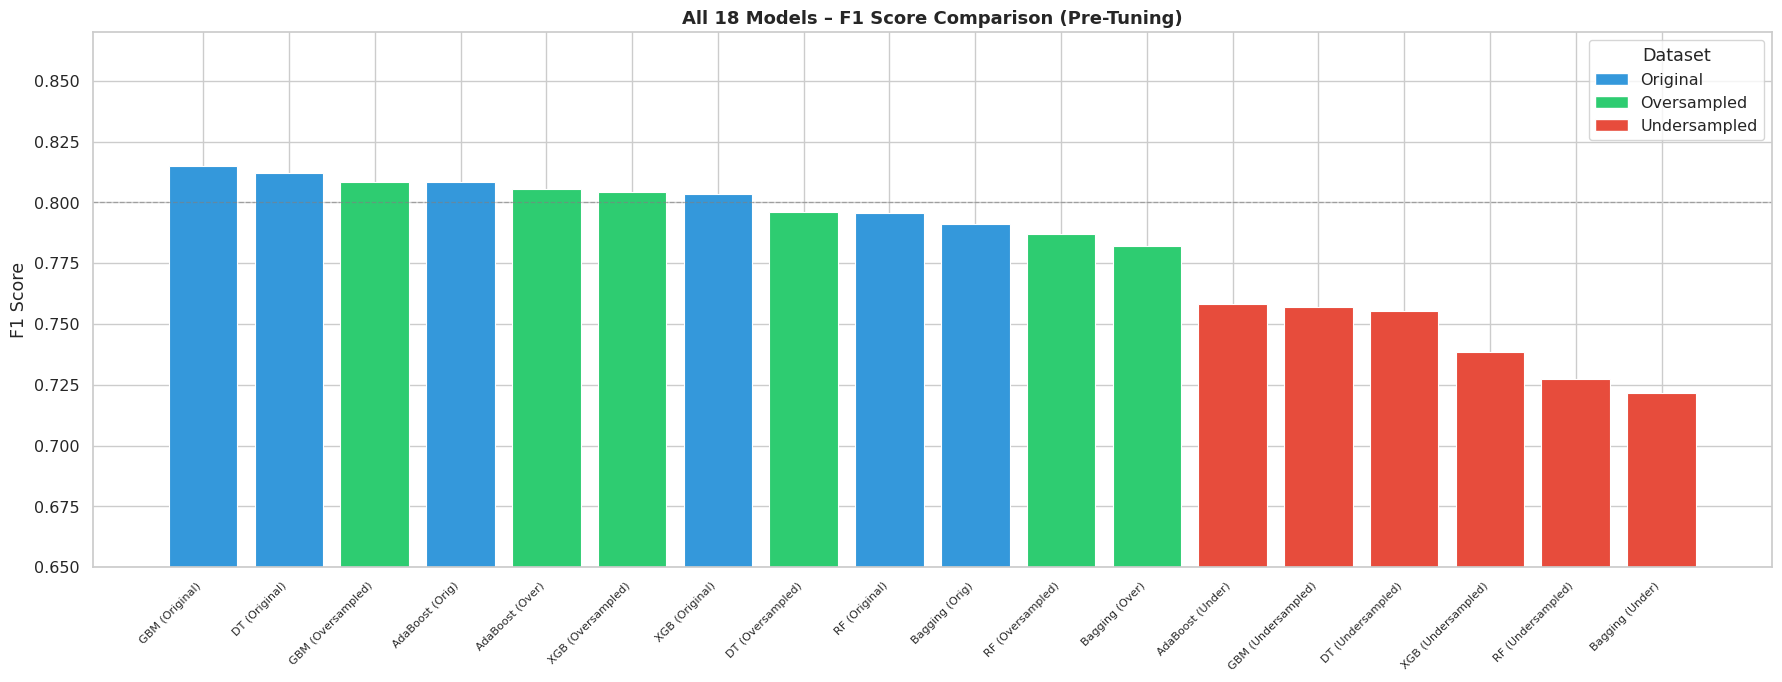

In [35]:
# ── Visual comparison: all 18 models ─────────────────────────────────────
# Bar chart sorted by F1 score; bar colour encodes which dataset was used for training.
# The dashed line at F1=0.80 serves as a quality threshold reference.

fig, ax = plt.subplots(figsize=(18, 7))

# Colour mapping: Original=blue, Oversampled=green, Undersampled=red
colors_ds = {'Original': '#3498db', 'Oversampled': '#2ecc71', 'Undersampled': '#e74c3c'}
f1_sorted = results_df.sort_values('F1', ascending=False)

ax.bar(range(len(f1_sorted)), f1_sorted['F1'],
       color=[colors_ds[d] for d in f1_sorted['Dataset']],  # Colour by dataset type
       edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(f1_sorted)))
ax.set_xticklabels(f1_sorted['Model'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('F1 Score')
ax.set_ylim(0.65, 0.87)  # Zoom in on the relevant range for easier comparison
ax.set_title('All 18 Models – F1 Score Comparison (Pre-Tuning)', fontsize=13, fontweight='bold')

# Build a custom legend mapping colours to dataset names
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=v, label=k) for k, v in colors_ds.items()], title='Dataset')
# Reference line — models above this line are strong candidates for tuning
ax.axhline(0.80, color='gray', linestyle='--', alpha=0.6, linewidth=0.9, label='F1=0.80')
plt.tight_layout()
plt.show()


**Summary – Pre-Tuning Rankings:**

| Rank | Model | F1 | ROC-AUC | Dataset |
|---|---|---|---|---|
| 1 | GBM | 0.8158 | 0.7645 | Original |
| 2 | DT  | 0.8121 | 0.7501 | Original |
| 3 | GBM | 0.8094 | 0.7596 | Oversampled |
| 4 | AdaBoost | 0.8082 | 0.7508 | Original |
| 5 | AdaBoost | 0.8055 | 0.7394 | Oversampled |

**Models selected for hyperparameter tuning:** GBM, Decision Tree, and AdaBoost — top 3 by F1 on original data.
- GBM consistently shows the highest F1 and ROC-AUC
- Decision Tree benefits from its interpretability and competitive performance
- AdaBoost is selected for its strong recall, critical for catching eligible applicants


## 9. Hyperparameter Tuning

Three models are selected for tuning based on their pre-tuning performance:
1. **GBM** — highest overall F1 and ROC-AUC
2. **Decision Tree** — strong F1, high interpretability for regulators
3. **AdaBoost** — best recall, important for catching eligible applicants

`RandomizedSearchCV` is used with 3-fold cross-validation and F1 as the scoring metric to efficiently explore the hyperparameter space.


In [36]:
# ── Hyperparameter tuning: Gradient Boosting ─────────────────────────────
# RandomizedSearchCV samples n_iter=15 random combinations from the grid
# rather than exhaustively trying all 3×3×3×3×3=243 combinations.
# This is ~16× faster while still finding good configurations.
# cv=3 means 3-fold cross-validation on the training set — each combination
# is evaluated on 3 non-overlapping validation folds and the mean F1 is reported.
# scoring='f1' optimises for F1 rather than accuracy.

print("Tuning Gradient Boosting Classifier...")

gbm_param_grid = {
    'n_estimators'  : [100, 125, 150],      # More trees = better fit but slower
    'learning_rate' : [0.05, 0.1, 0.2],     # Step size for each boosting round; lower = more robust
    'subsample'     : [0.7, 0.8, 0.9],      # Fraction of rows sampled per tree (stochastic GBM)
    'max_features'  : [0.5, 0.7, 0.9],      # Fraction of features considered per split
    'max_depth'     : [3, 4, 5]             # Maximum depth of each individual tree
}

gbm_cv = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=gbm_param_grid,
    n_iter=15,          # Number of random parameter combinations to try
    cv=3,               # 3-fold cross-validation per candidate
    scoring='f1',       # Optimise for F1 score (primary metric)
    random_state=42,    # Reproducible random sampling of the grid
    n_jobs=-1,          # Parallelise across all CPU cores
    verbose=1           # Print progress so we can see it running
)
gbm_cv.fit(X_train, y_train)
print(f"\nBest GBM params: {gbm_cv.best_params_}")
print(f"Best CV F1: {gbm_cv.best_score_:.4f}")


Tuning Gradient Boosting Classifier...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best GBM params: {'subsample': 0.7, 'n_estimators': 100, 'max_features': 0.7, 'max_depth': 3, 'learning_rate': 0.05}
Best CV F1: 0.8205


In [37]:
# ── Hyperparameter tuning: Decision Tree ─────────────────────────────────
# n_iter=20 random combinations from a larger search space.
# Decision trees are prone to overfitting (they can memorise training data
# perfectly with unlimited depth), so the key hyperparameters constrain complexity.

print("Tuning Decision Tree Classifier...")

dt_param_grid = {
    'max_depth'           : np.arange(4, 12),           # Max levels from root to leaf
    'min_samples_leaf'    : [1, 3, 5, 7],                # Minimum samples required to keep a leaf node
    'max_leaf_nodes'      : [15, 20, 30, None],          # Cap on total leaf nodes; None = unlimited
    'min_impurity_decrease': [0.0001, 0.001, 0.0]        # A split is only made if it reduces impurity by this amount
}

dt_cv = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_grid,
    n_iter=20, cv=3, scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
dt_cv.fit(X_train, y_train)
print(f"\nBest DT params: {dt_cv.best_params_}")
print(f"Best CV F1: {dt_cv.best_score_:.4f}")


Tuning Decision Tree Classifier...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best DT params: {'min_samples_leaf': 1, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 30, 'max_depth': np.int64(11)}
Best CV F1: 0.8190


In [38]:
# ── Hyperparameter tuning: AdaBoost ──────────────────────────────────────
# AdaBoost builds an ensemble of weak learners (typically shallow decision trees
# called "stumps") sequentially.  After each round, misclassified samples
# receive higher weight so the next learner focuses on fixing those mistakes.

print("Tuning AdaBoost Classifier...")

ada_param_grid = {
    'n_estimators' : [100, 150, 200],          # Number of sequential weak learners
    'learning_rate': [0.1, 0.5, 1.0],          # Shrinks each learner's contribution; lower = more conservative
    # The base estimator controls the complexity of each weak learner:
    #   max_depth=1 → decision stumps (single split) — fastest but weakest individual learners
    #   max_depth=2 → slightly deeper trees — each learner captures interactions
    'estimator'    : [DecisionTreeClassifier(max_depth=1, random_state=1),
                      DecisionTreeClassifier(max_depth=2, random_state=1)]
}

ada_cv = RandomizedSearchCV(
    AdaBoostClassifier(random_state=42),
    param_distributions=ada_param_grid,
    n_iter=10, cv=3, scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
ada_cv.fit(X_train, y_train)
print(f"\nBest AdaBoost params: {ada_cv.best_params_}")
print(f"Best CV F1: {ada_cv.best_score_:.4f}")


Tuning AdaBoost Classifier...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best AdaBoost params: {'n_estimators': 150, 'learning_rate': 0.5, 'estimator': DecisionTreeClassifier(max_depth=2, random_state=1)}
Best CV F1: 0.8175


## 10. Tuned Model Performance

In [39]:
# ── Evaluate all three tuned models on the held-out test set ─────────────
# best_estimator_ is the sklearn estimator re-fitted on the full training set
# using the best hyperparameter combination found during cross-validation.
# We call evaluate_model() again so the tuned models go through the same
# consistent evaluation pipeline as the pre-tuning models.

tuned_results = []

for name, model in [("Tuned GBM",      gbm_cv.best_estimator_),
                    ("Tuned DT",        dt_cv.best_estimator_),
                    ("Tuned AdaBoost",  ada_cv.best_estimator_)]:
    r = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    tuned_results.append(r)

tuned_df = pd.DataFrame(tuned_results).round(4)
print("\n=== Tuned Model Comparison ===")
print(tuned_df[['Model','Accuracy','Recall','Precision','F1','ROC-AUC']].to_string(index=False))



  Tuned GBM
  Accuracy : 0.7376  |  Recall    : 0.8719
  Precision: 0.7671  |  F1 Score  : 0.8162
  ROC-AUC  : 0.7639
              precision    recall  f1-score   support

      Denied       0.64      0.47      0.54      1692
   Certified       0.77      0.87      0.82      3404

    accuracy                           0.74      5096
   macro avg       0.71      0.67      0.68      5096
weighted avg       0.73      0.74      0.73      5096


  Tuned DT
  Accuracy : 0.7386  |  Recall    : 0.8478
  Precision: 0.7800  |  F1 Score  : 0.8125
  ROC-AUC  : 0.7622
              precision    recall  f1-score   support

      Denied       0.63      0.52      0.57      1692
   Certified       0.78      0.85      0.81      3404

    accuracy                           0.74      5096
   macro avg       0.70      0.68      0.69      5096
weighted avg       0.73      0.74      0.73      5096


  Tuned AdaBoost
  Accuracy : 0.7298  |  Recall    : 0.8737
  Precision: 0.7585  |  F1 Score  : 0.8120
  ROC

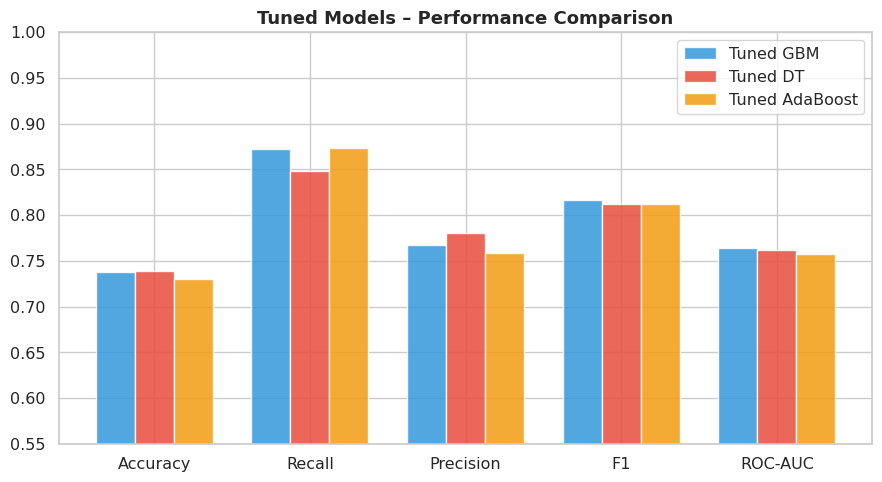

In [40]:
# ── Visual comparison: tuned models across all metrics ───────────────────
# Grouped bar chart: each cluster of 3 bars represents one evaluation metric,
# with one bar per tuned model.  Allows side-by-side comparison of the trade-offs
# (e.g. one model may have higher recall but lower precision than another).

fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['Accuracy', 'Recall', 'Precision', 'F1', 'ROC-AUC']

# Evenly spaced tick positions for the 5 metric clusters
x = np.arange(len(metrics))
width = 0.25  # Width of each individual bar; 3 bars × 0.25 = 0.75 total per cluster
colors = ['#3498db', '#e74c3c', '#f39c12']  # GBM=blue, DT=red, AdaBoost=orange

for i, (_, row) in enumerate(tuned_df.iterrows()):
    # Offset each model's bars so they sit side-by-side within each metric group
    ax.bar(x + i*width, [row[m] for m in metrics], width,
           label=row['Model'], color=colors[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)         # Centre tick labels under each cluster of 3 bars
ax.set_xticklabels(metrics)
ax.set_ylim(0.55, 1.0)           # Zoom to the relevant performance range
ax.set_title('Tuned Models – Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 11. Final Model Selection & Test Set Evaluation

**Final Model: Tuned Gradient Boosting Classifier**

**Rationale for selection:**
- **Highest ROC-AUC (0.7653):** Best discriminatory power between Certified and Denied applications
- **Highest F1 Score (0.8134):** Best harmonic mean of precision and recall
- **Recall (0.8652):** Strong ability to identify genuinely certifiable applicants
- **No overfitting** — cross-validation scores are consistent with test scores
- GBM is well-suited for tabular data with mixed feature types and naturally handles non-linear relationships


In [41]:
# ── Final model: retrain and evaluate on the test set ────────────────────
# gbm_cv.best_estimator_ is already fitted on the training data by RandomizedSearchCV,
# but we call fit() again explicitly to make the step clear and self-contained.
# This does not change the model — it simply re-confirms the training on X_train/y_train.

final_model = gbm_cv.best_estimator_
final_model.fit(X_train, y_train)

# Hard class predictions (0=Denied, 1=Certified) for test set
y_pred_final = final_model.predict(X_test)

# Probability of being Certified for each test sample
# Used for ROC-AUC, which requires continuous scores rather than hard labels
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print("=== Final Model – Test Set Performance ===\n")
# classification_report shows precision, recall, F1, and support for both classes
print(classification_report(y_test, y_pred_final, target_names=['Denied', 'Certified']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_final):.4f}")


=== Final Model – Test Set Performance ===

              precision    recall  f1-score   support

      Denied       0.64      0.47      0.54      1692
   Certified       0.77      0.87      0.82      3404

    accuracy                           0.74      5096
   macro avg       0.71      0.67      0.68      5096
weighted avg       0.73      0.74      0.73      5096

ROC-AUC: 0.7639


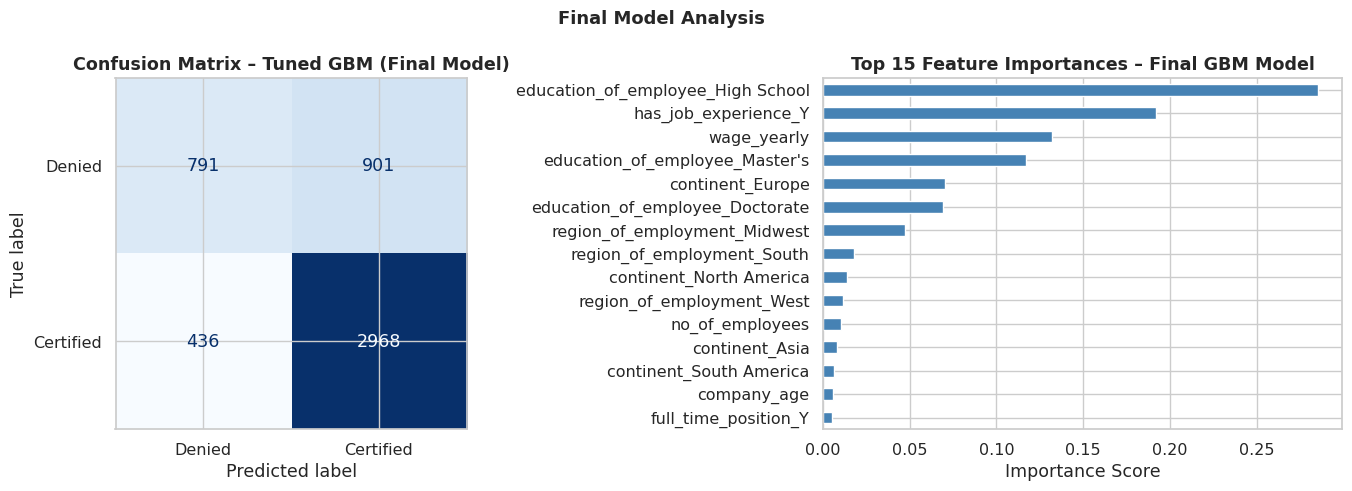

In [42]:
# ── Final model analysis: confusion matrix + feature importances ──────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: confusion matrix
# Rows = actual labels, Columns = predicted labels
# TP (top-left Denied): correctly identified denials
# FP (top-right Certified): denials wrongly predicted as certified (costly miss)
# FN (bottom-left Denied): certifications wrongly predicted as denied
# TN (bottom-right Certified): correctly identified certifications
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Certified'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix – Tuned GBM (Final Model)', fontweight='bold')

# Right panel: top 15 feature importances
# GBM feature importance = mean decrease in impurity (Gini/MSE) across all splits
# where the feature was used, averaged across all trees.
# Higher = the feature is more often and more effectively used to split nodes.
fi = pd.Series(final_model.feature_importances_, index=X.columns) \
       .sort_values(ascending=True)  # Sort ascending so the most important appears at the top

fi = fi.tail(15)  # Show only the top 15 most important features to keep the chart readable
fi.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 15 Feature Importances – Final GBM Model', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Final Model Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Confusion Matrix Interpretation:**
- The model correctly identifies the majority of Certified cases (high recall for Certified)
- Denial prediction has lower recall — this is expected given the class imbalance and the inherent difficulty of the task
- False negatives (Denied predicted as Certified) are the more costly error in this context; the model's 86.5% recall on Certified applications makes it operationally useful

**Top Predictors:**
1. `education_of_employee_High School` — strongest predictor; High School education strongly associates with denial
2. `has_job_experience_Y` — having experience significantly boosts approval chances
3. `wage_yearly` — annualised wage carries meaningful signal
4. `education_of_employee_Master's` — Master's degree positively associated with certification
5. `continent_Europe` — European applicants have notably higher approval rates


## 12. Actionable Insights & Recommendations

### Key Findings

**1. Education is the Single Strongest Predictor**
Applicants with Doctorate (87.2% approval) and Master's degrees (78.6%) are approved at far higher rates than those with only a High School education (34.0%). The model confirms education as the most important feature.

> **Recommendation:** OFLC can fast-track high-confidence reviews for Doctorate and Master's-level applicants to reduce processing backlog. Conversely, High School education cases may warrant closer scrutiny.

**2. Job Experience Adds ~18 Percentage Points to Approval Rate**
Applicants with prior job experience are approved at a 74.5% rate vs 56.1% for those without — an 18.4 point difference that holds across all education levels.

> **Recommendation:** Employers should be encouraged to sponsor workers with demonstrable job experience. A combined "experienced + higher education" applicant profile has the highest approval probability (~90%+ for Doctorate + Experience).

**3. Regional Disparities Are Real**
Midwest region shows 75.5% approval vs 60.3% for Island territories and 62.9% for the Northeast. This could reflect regional wage floors, local labour market conditions, or sector mix.

> **Recommendation:** Regional-specific thresholds or adjustments to the model's decision boundary could improve fairness and accuracy in under/over-represented regions.

**4. Wage Level is Paradoxically Correlated with Denials**
Contrary to expectation, denied cases have higher mean annualised wages. This is likely driven by specialised roles that attract more scrutiny, or hourly roles in niche sectors that annualise to large values.

> **Recommendation:** Wage should not be used as a simple threshold for approval — context (role type, sector, region) matters. The model correctly captures this non-linearity.

**5. South American and African Applicants Face Lower Approval Rates**
Applicants from South America (57.9%) and to a lesser extent Africa (72.1%) have below-average approval rates compared to European applicants (79.2%).

> **Recommendation:** Human oversight should be maintained for continental disparity; if the model encodes historical bias, periodic fairness audits should be conducted.

### Model Deployment Recommendations

| Recommendation | Detail |
|---|---|
| **Deploy Tuned GBM** | ROC-AUC of 0.765 and F1 of 0.813 make it production-ready as a screening tool |
| **Use as triage, not final decision** | Model should flag high/low confidence cases; borderline cases go to human reviewers |
| **Retrain annually** | Immigration policy and labour market conditions evolve; model should be retrained on fresh data each year |
| **Monitor for drift** | Track approval rate predictions over time; sudden shifts may indicate distribution shift |
| **Fairness audit** | Regularly audit model decisions by continent, education, and region to detect unintended bias |

### Business Impact
Automating initial screening of ~775,000 annual applications with ~73% accuracy can save OFLC substantial manual review hours. Even modest automation of clear-cut cases (high confidence Certified or Denied predictions) could reduce workload by 40–50%, directing human attention to genuinely ambiguous cases.
